# Multivariate Exploratory Analysis vs. Pairwise Analysis
## Wine Quality Dataset Comparison

**Objective:** Compare traditional pairwise exploratory analysis with multivariate exploratory techniques to reveal global patterns and structures in the Wine Quality dataset that are not apparent through pairwise analysis alone.

### Dataset Overview
- **Source:** Wine Quality datasets (Red and White variants)
- **Red wine samples:** 1,599
- **White wine samples:** 4,898
- **Physicochemical variables:** 11 continuous attributes
- **Target variable:** Quality (ordinal, 0-10)

### Variables
1. Fixed acidity
2. Volatile acidity
3. Citric acid
4. Residual sugar
5. Chlorides
6. Free sulfur dioxide
7. Total sulfur dioxide
8. Density
9. pH
10. Sulphates
11. Alcohol
12. Quality (target)

## 1. Import Required Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

## 2. Load and Prepare Data

In [20]:
# Load datasets
red_wine = pd.read_csv('data/wine+quality/winequality-red.csv', sep=';')
white_wine = pd.read_csv('data/wine+quality/winequality-white.csv', sep=';')

# Add type identifier
red_wine['wine_type'] = 'Red'
white_wine['wine_type'] = 'White'

# Combine datasets
df = pd.concat([red_wine, white_wine], ignore_index=True)

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (6497, 13)

First few rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality wine_type  
0      9.4 

In [21]:
# Distribuição de qualidade por tipo
print("Quality Distribution:")
print("\nRed Wine:")
print(red_wine['quality'].value_counts().sort_index())
print("\nWhite Wine:")
print(white_wine['quality'].value_counts().sort_index())

Quality Distribution:

Red Wine:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

White Wine:
quality
3      20
4     163
5    1457
6    2198
7     880
8     175
9       5
Name: count, dtype: int64


## 3. Exploratory Data Analysis (EDA)

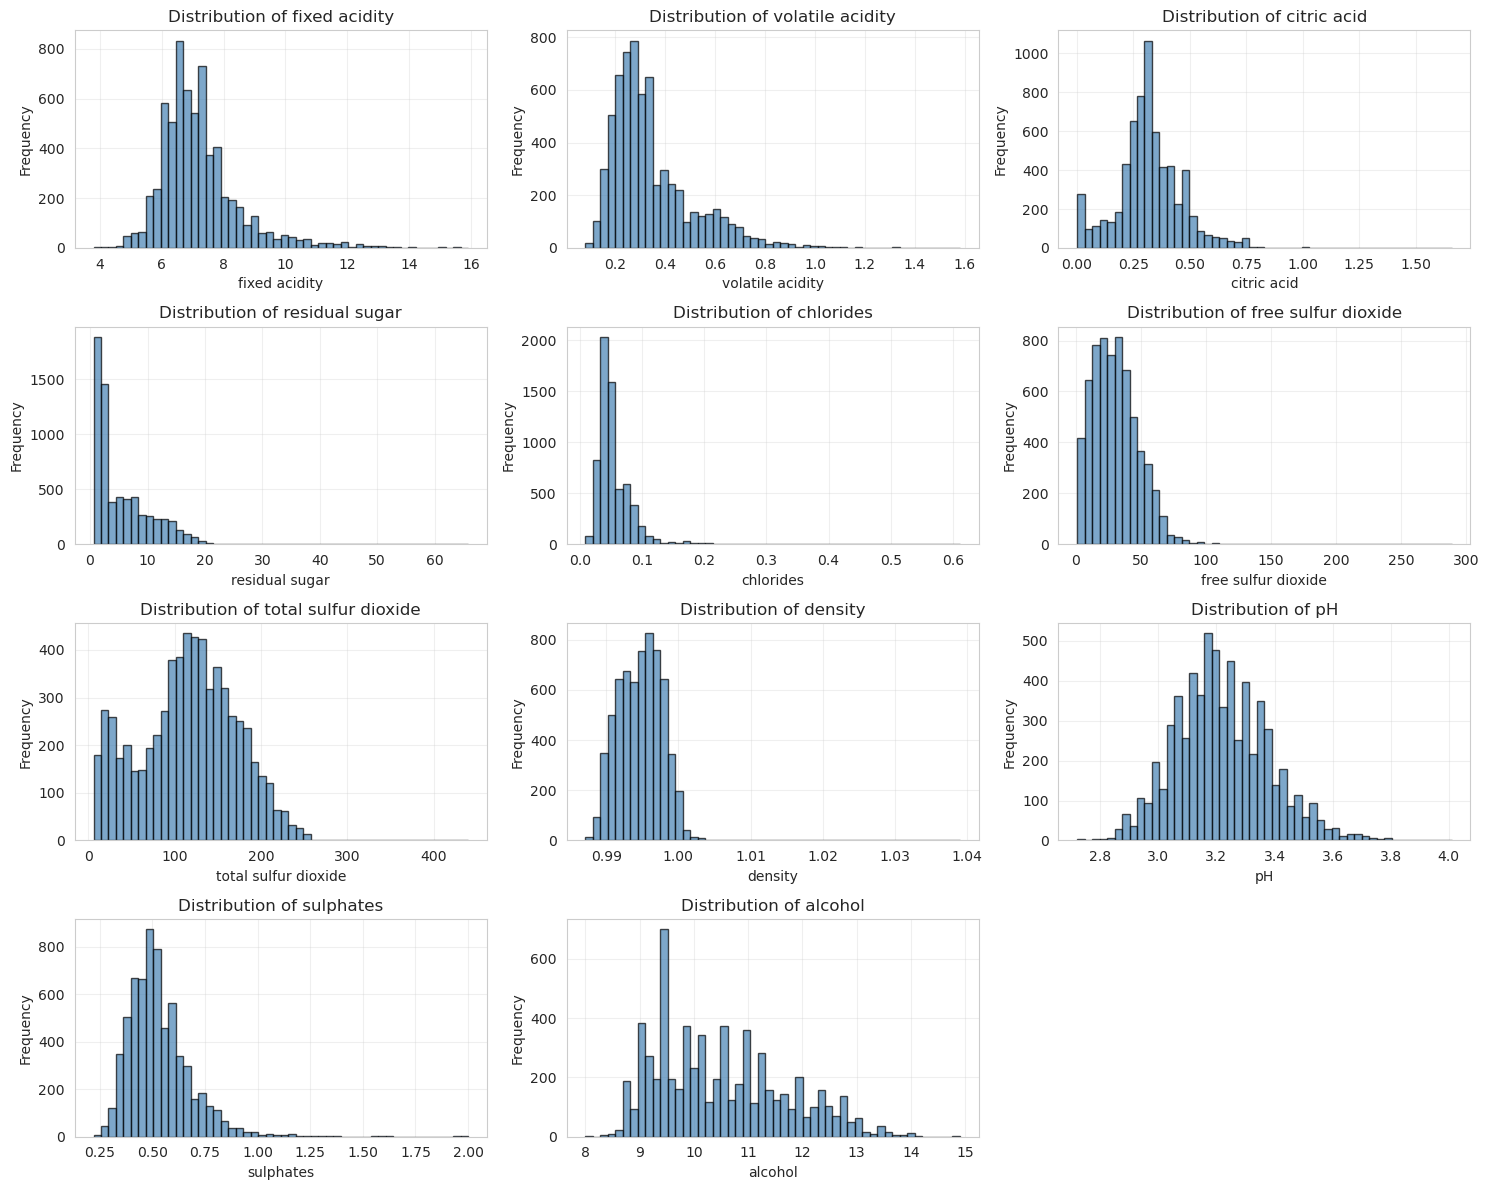

In [22]:
# Distributions of physicochemical variables
features = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
            'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
            'pH', 'sulphates', 'alcohol']

fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, feature in enumerate(features):
    axes[idx].hist(df[feature], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {feature}')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

# Remove the extra subplot
fig.delaxes(axes[11])

plt.tight_layout()
plt.show()

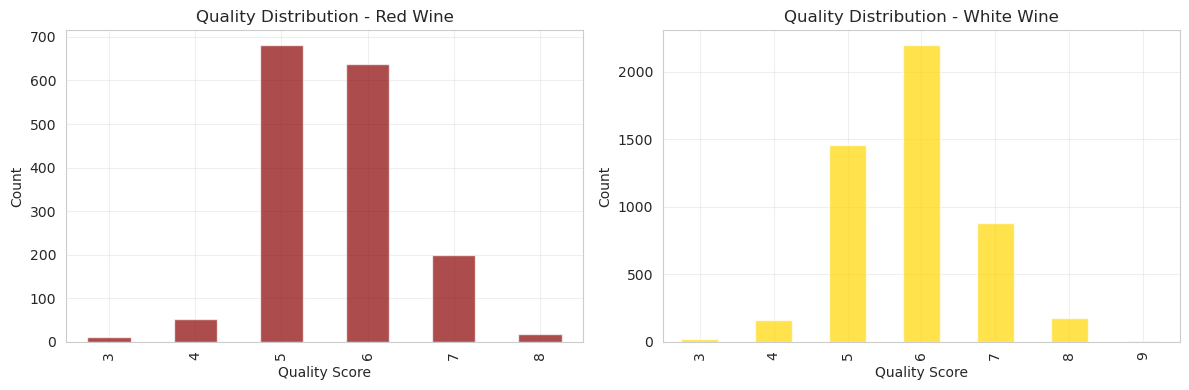

In [23]:
# Quality distribution by wine type
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

red_wine['quality'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='darkred', alpha=0.7)
axes[0].set_title('Quality Distribution - Red Wine')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

white_wine['quality'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='gold', alpha=0.7)
axes[1].set_title('Quality Distribution - White Wine')
axes[1].set_xlabel('Quality Score')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. PAIRWISE ANALYSIS: Traditional Approach

This section demonstrates traditional exploratory analysis using pairwise relationships.

**Limitations:** While pairwise analysis reveals relationships between pairs of variables, it does not capture:
- Global patterns across multiple dimensions
- Latent structures or common underlying factors
- Relationships among quality groups in multi-dimensional space
- The true dimensionality of the data

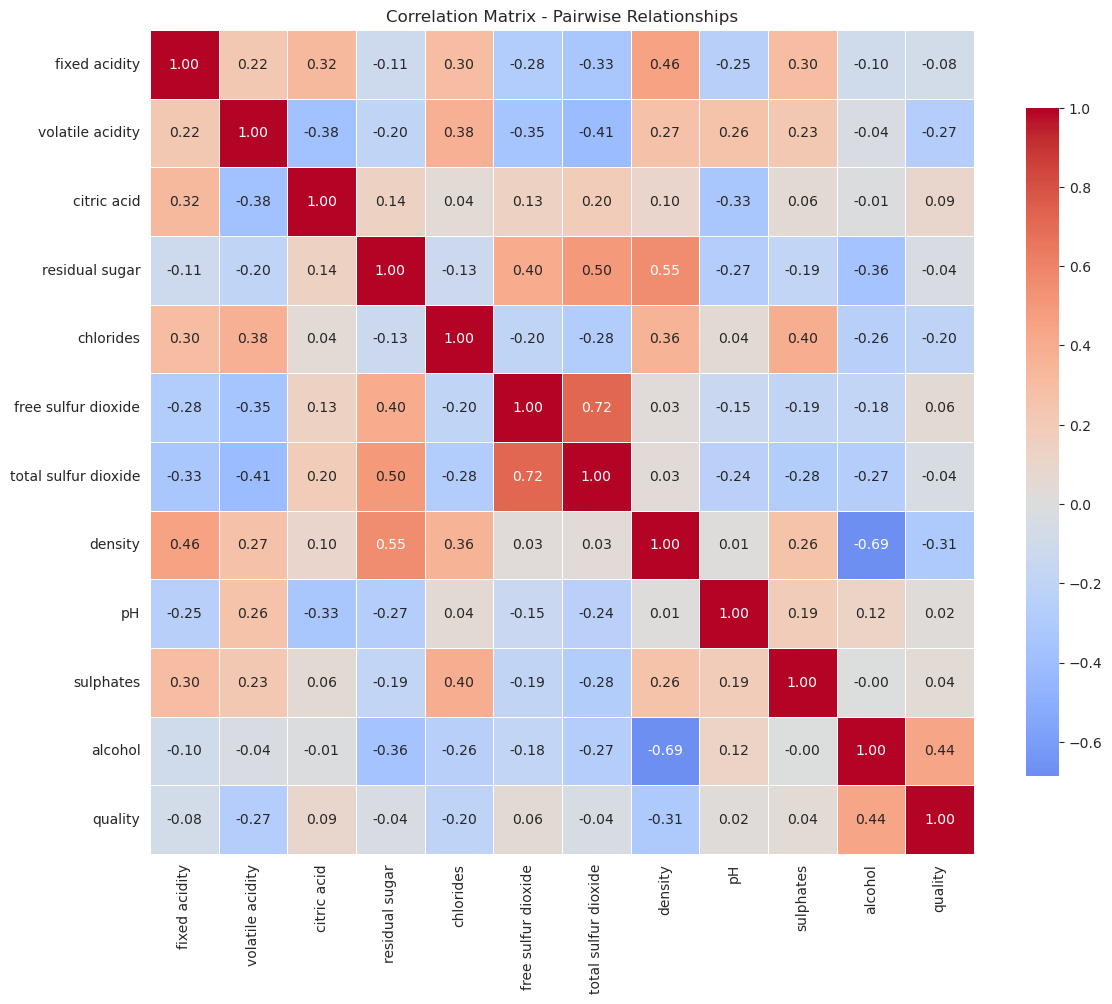


Correlation with Quality:
quality                 1.000000
alcohol                 0.444319
citric acid             0.085532
free sulfur dioxide     0.055463
sulphates               0.038485
pH                      0.019506
residual sugar         -0.036980
total sulfur dioxide   -0.041385
fixed acidity          -0.076743
chlorides              -0.200666
volatile acidity       -0.265699
density                -0.305858
Name: quality, dtype: float64


In [24]:
# Correlation matrix
corr_matrix = df[features + ['quality']].corr()

# Visualize correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Pairwise Relationships')
plt.tight_layout()
plt.show()

print("\nCorrelation with Quality:")
print(corr_matrix['quality'].sort_values(ascending=False))


Top 6 features correlated with quality: ['alcohol', 'density', 'volatile acidity', 'chlorides', 'citric acid', 'fixed acidity']


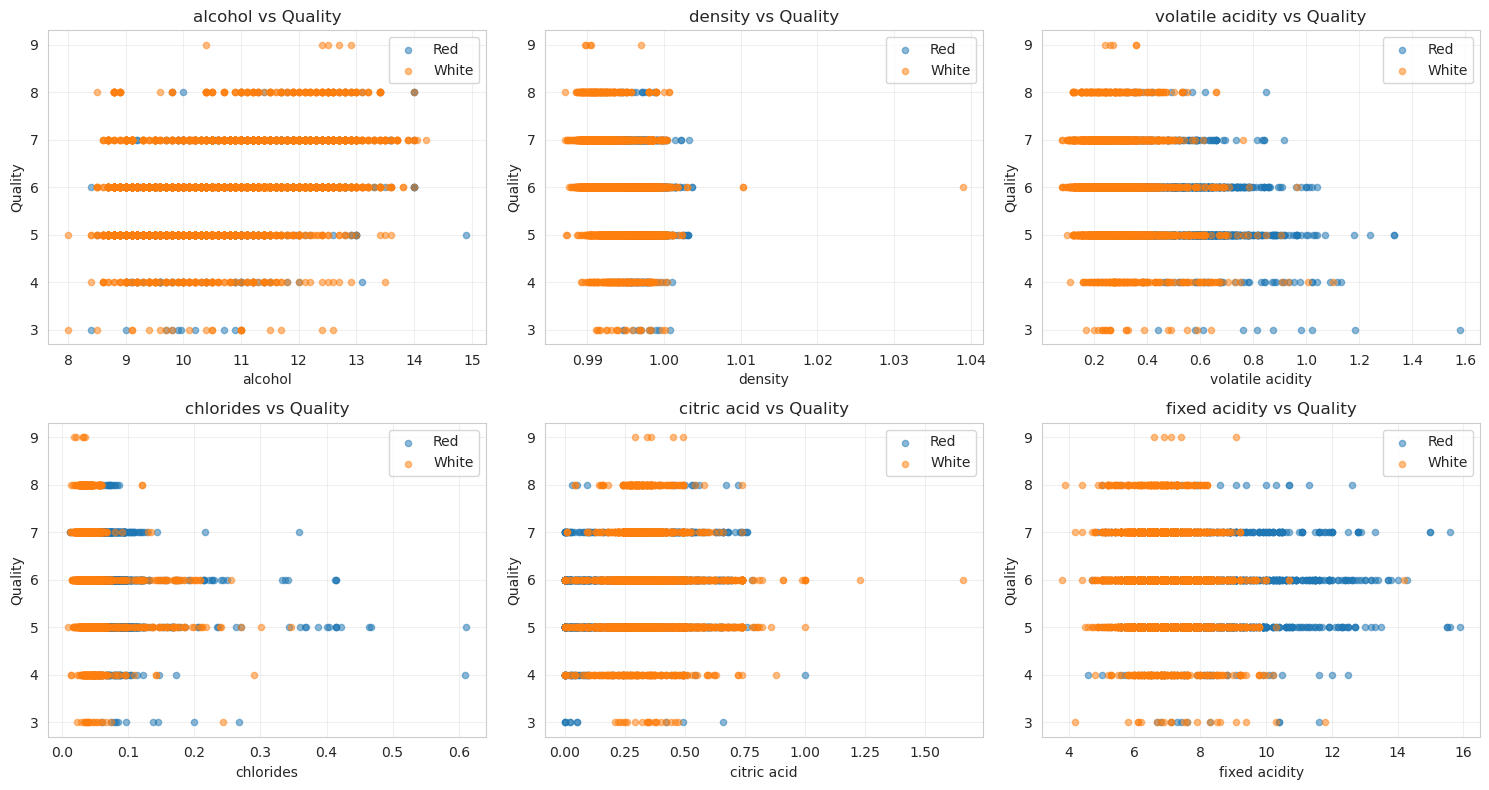

In [25]:
# Scatter plots of top correlated features with quality
top_features = corr_matrix['quality'].abs().sort_values(ascending=False)[1:7].index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

print(f"\nTop 6 features correlated with quality: {top_features}")

for idx, feature in enumerate(top_features):
    for wine_type in ['Red', 'White']:
        data = df[df['wine_type'] == wine_type]
        axes[idx].scatter(data[feature], data['quality'], 
                         label=wine_type, alpha=0.5, s=20)
    
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Quality')
    axes[idx].set_title(f'{feature} vs Quality')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. MULTIVARIATE ANALYSIS: Advanced Approach

This section applies multivariate exploratory techniques to reveal global patterns.

**Advantages:** Multivariate methods reveal:
- Data structure across all dimensions simultaneously
- Underlying latent factors (PCA)
- Natural groupings and clusters
- True dimensionality of the data
- Complex interactions among variables

### 5.1 Principal Component Analysis (PCA)

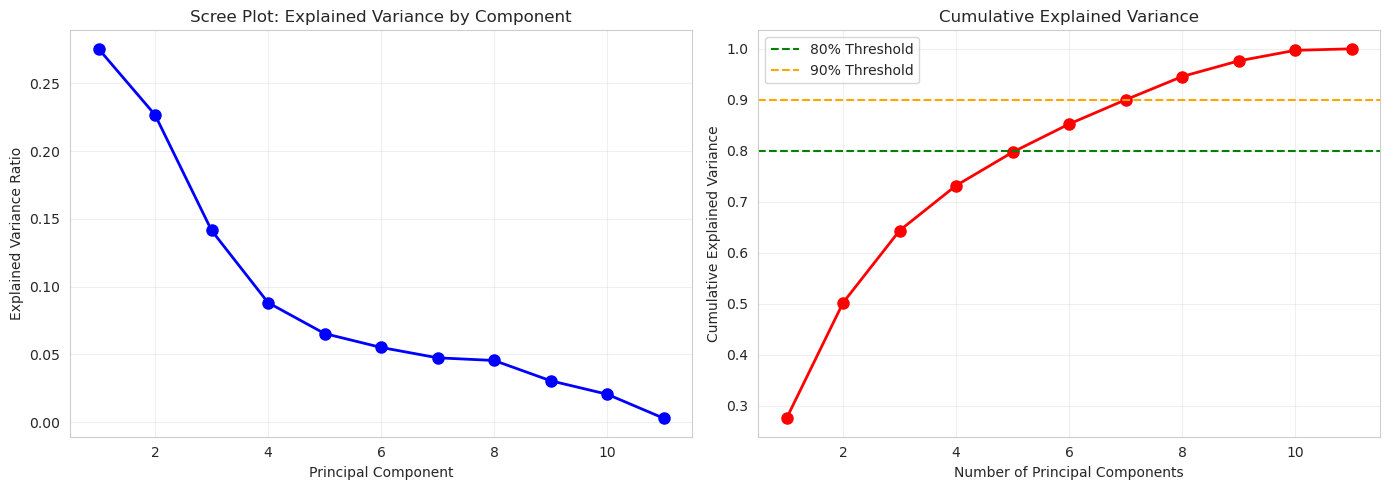

Explained Variance by Component:
PC1: 0.2754 (Cumulative: 0.2754)
PC2: 0.2267 (Cumulative: 0.5022)
PC3: 0.1415 (Cumulative: 0.6436)
PC4: 0.0882 (Cumulative: 0.7319)
PC5: 0.0654 (Cumulative: 0.7973)
PC6: 0.0552 (Cumulative: 0.8525)
PC7: 0.0476 (Cumulative: 0.9001)
PC8: 0.0456 (Cumulative: 0.9457)
PC9: 0.0306 (Cumulative: 0.9763)
PC10: 0.0207 (Cumulative: 0.9970)
PC11: 0.0030 (Cumulative: 1.0000)


In [26]:
# Prepare data: standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# Apply PCA
pca_full = PCA()
pca_full.fit(X_scaled)

# Explained variance
explained_var = pca_full.explained_variance_ratio_
cumsum_var = np.cumsum(explained_var)

# Visualize explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].plot(range(1, len(explained_var) + 1), explained_var, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot: Explained Variance by Component')
axes[0].grid(True, alpha=0.3)

# Cumulative explained variance
axes[1].plot(range(1, len(cumsum_var) + 1), cumsum_var, 'ro-', linewidth=2, markersize=8)
axes[1].axhline(y=0.80, color='g', linestyle='--', label='80% Threshold')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90% Threshold')
axes[1].set_xlabel('Number of Principal Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Explained Variance by Component:")
for i, (var, cumsum) in enumerate(zip(explained_var, cumsum_var), 1):
    print(f"PC{i}: {var:.4f} (Cumulative: {cumsum:.4f})")

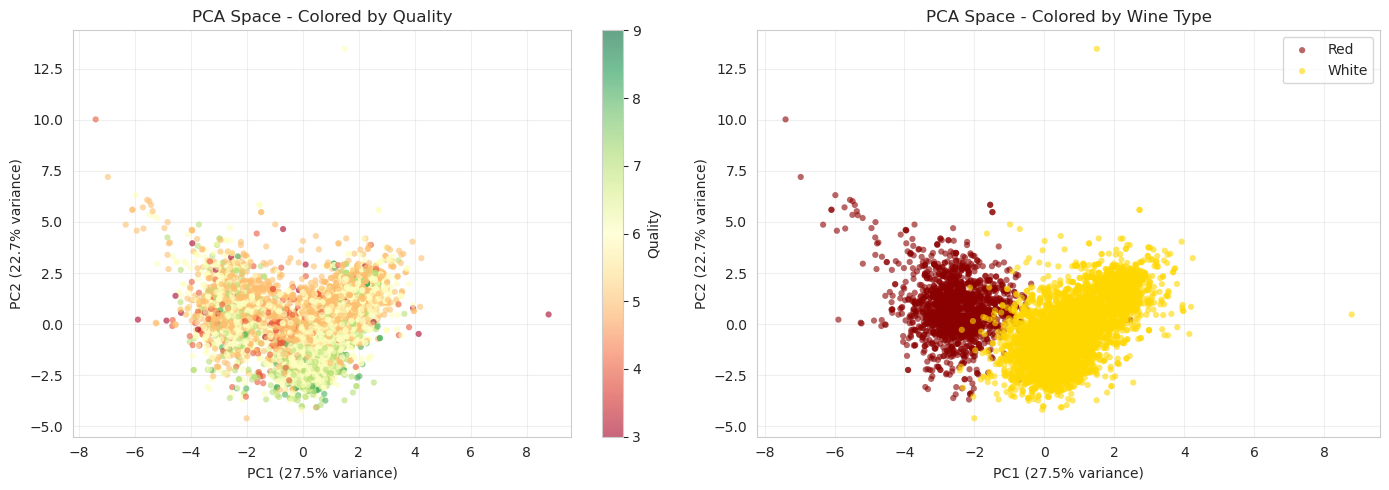

In [27]:
# 2D PCA visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By quality
scatter1 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=df['quality'], 
                           cmap='RdYlGn', s=20, alpha=0.6, edgecolors='none')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
axes[0].set_title('PCA Space - Colored by Quality')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Quality')

# By wine type
colors_wine = {'Red': 'darkred', 'White': 'gold'}
for wine_type in ['Red', 'White']:
    mask = df['wine_type'] == wine_type
    axes[1].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], 
                   label=wine_type, color=colors_wine[wine_type], s=20, alpha=0.6, edgecolors='none')

axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
axes[1].set_title('PCA Space - Colored by Wine Type')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

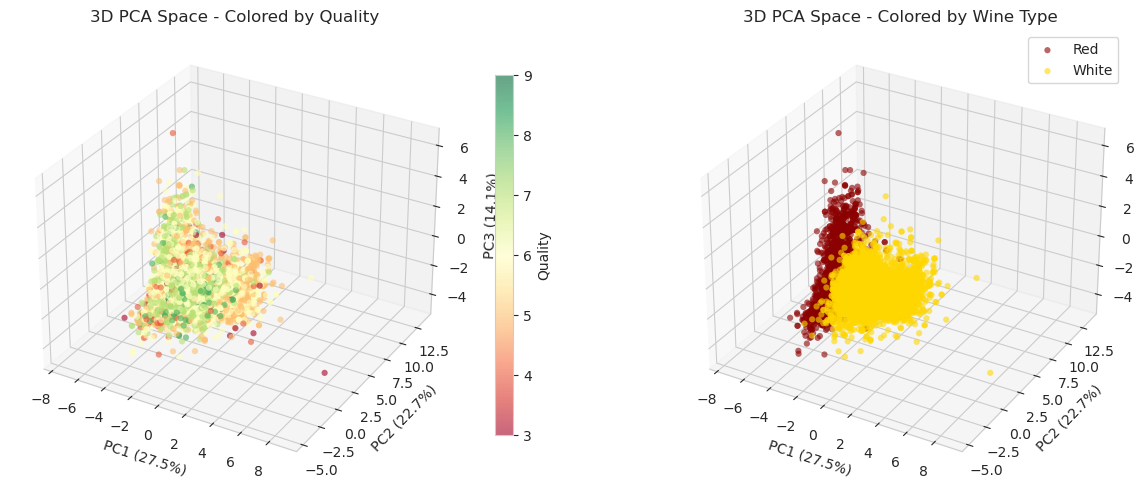

In [28]:
# 3D visualization of PCA
from mpl_toolkits.mplot3d import Axes3D

# 3D PCA visualization
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(14, 5))

# 3D PCA colored by quality
ax1 = fig.add_subplot(121, projection='3d')
scatter_3d = ax1.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], 
                        c=df['quality'], cmap='RdYlGn', s=20, alpha=0.6, edgecolors='none')
ax1.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})')
ax1.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})')
ax1.set_title('3D PCA Space - Colored by Quality')
plt.colorbar(scatter_3d, ax=ax1, label='Quality', shrink=0.8)

# 3D PCA colored by wine type
ax2 = fig.add_subplot(122, projection='3d')
for wine_type in ['Red', 'White']:
    mask = df['wine_type'] == wine_type
    ax2.scatter(X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
               label=wine_type, color=colors_wine[wine_type], s=20, alpha=0.6, edgecolors='none')

ax2.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})')
ax2.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})')
ax2.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})')
ax2.set_title('3D PCA Space - Colored by Wine Type')
ax2.legend()

plt.tight_layout()
plt.show()

### 5.2 Clustering Analysis

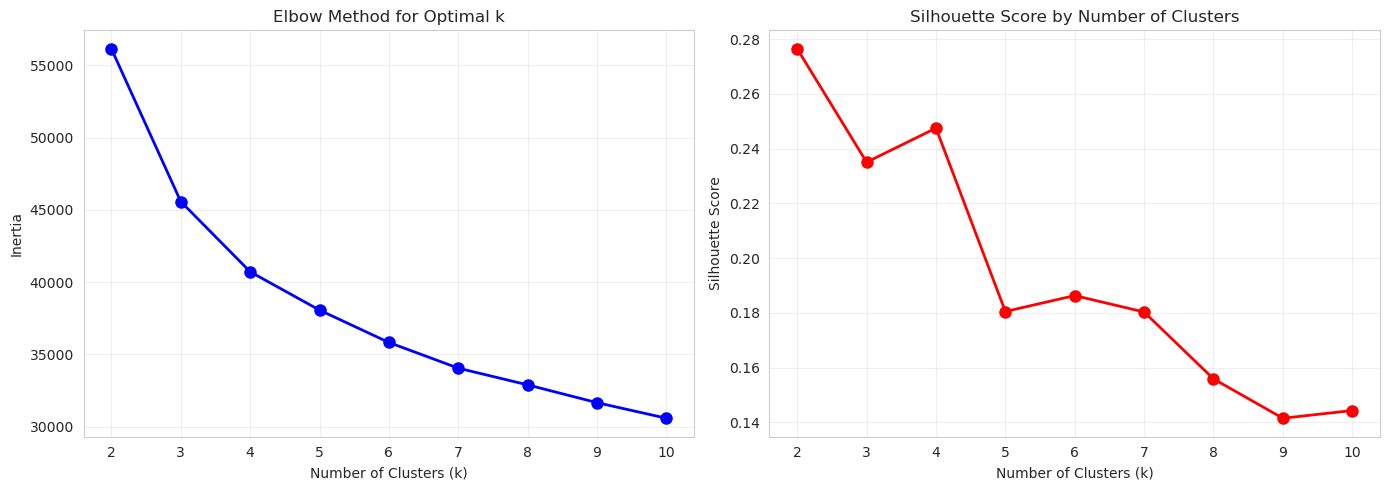

Best k by silhouette score: 2


In [29]:
# Determine optimal number of clusters using elbow method
inertias = []
silhouette_scores = []
K_range = range(2, 11)

from sklearn.metrics import silhouette_score

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method for Optimal k')
axes[0].grid(True, alpha=0.3)

# Silhouette score
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by Number of Clusters')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best k by silhouette score: {K_range[np.argmax(silhouette_scores)]}")

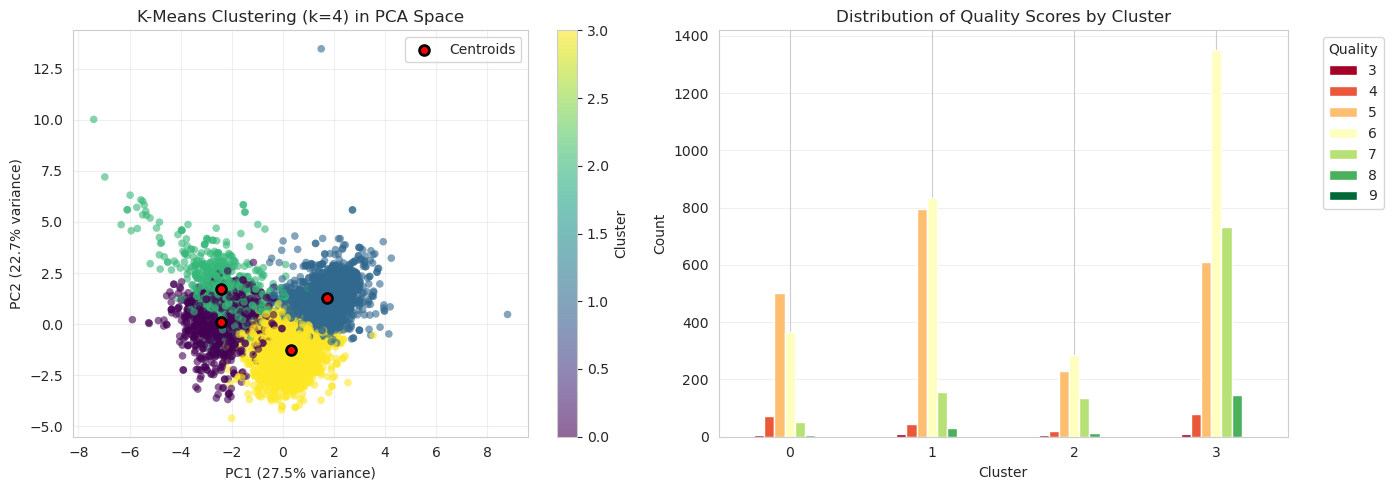

In [30]:
# K-means clustering with optimal k
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df['cluster'] = clusters

# Visualize clusters in PCA space
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-means clusters
scatter1 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=clusters, 
                           cmap='viridis', s=30, alpha=0.6, edgecolors='none')
# Plot cluster centers (in PCA space)
centers_pca = pca_2d.transform(kmeans.cluster_centers_)
axes[0].scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', marker='o', 
               s=50, edgecolors='black', linewidth=2, label='Centroids')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
axes[0].set_title(f'K-Means Clustering (k={optimal_k}) in PCA Space')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Cluster distribution by quality
cluster_quality = pd.crosstab(df['cluster'], df['quality'])
cluster_quality.plot(kind='bar', ax=axes[1], colormap='RdYlGn')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Quality Scores by Cluster')
axes[1].legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, alpha=0.3, axis='y')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=0)

plt.tight_layout()
plt.show()

Cluster Profiles (Mean Values):
         fixed acidity  volatile acidity  citric acid  residual sugar  \
cluster                                                                 
0                7.256             0.608        0.137           2.508   
1                6.963             0.281        0.358          11.231   
2                9.714             0.416        0.460           2.768   
3                6.777             0.267        0.323           3.379   

         chlorides  free sulfur dioxide  total sulfur dioxide  density     pH  \
cluster                                                                         
0            0.078               16.829                53.384    0.996  3.373   
1            0.052               45.701               170.083    0.997  3.157   
2            0.100               14.894                47.317    0.997  3.203   
3            0.040               29.193               118.463    0.992  3.209   

         sulphates  alcohol  quality  
clu

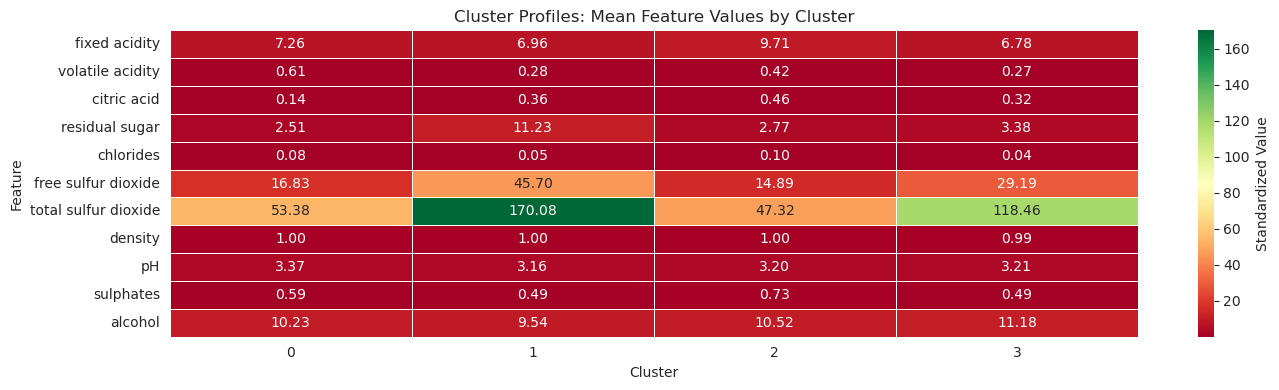

In [31]:
# Profile clusters: mean values of original features
cluster_profiles = df.groupby('cluster')[features + ['quality']].mean()

print("Cluster Profiles (Mean Values):")
print(cluster_profiles.round(3))

# Heatmap of cluster profiles
plt.figure(figsize=(14, 4))
sns.heatmap(cluster_profiles[features].T, annot=True, fmt='.2f', cmap='RdYlGn', 
            cbar_kws={'label': 'Standardized Value'}, linewidths=0.5)
plt.title('Cluster Profiles: Mean Feature Values by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

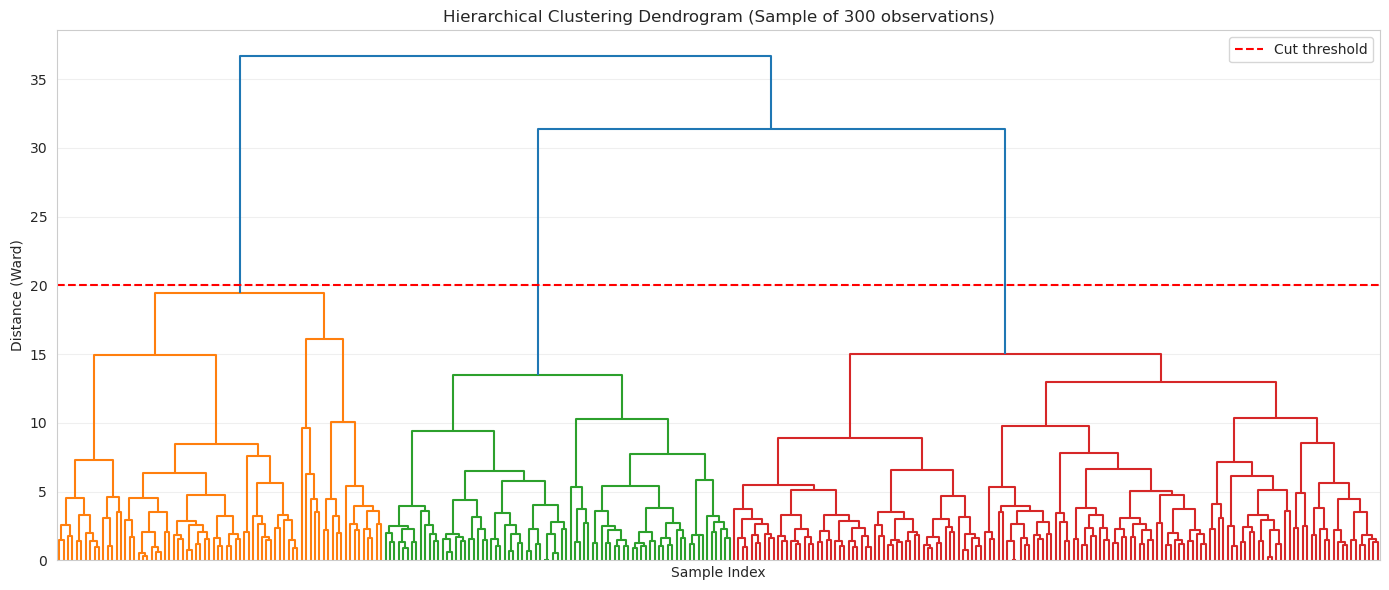

In [32]:
# Hierarchical clustering (on a sample to avoid overcrowding)
sample_size = 300
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[sample_idx]

# Compute linkage
linkage_matrix = linkage(X_sample, method='ward')

# Dendrogram
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(linkage_matrix, ax=ax, no_labels=True, color_threshold=20)
ax.set_title('Hierarchical Clustering Dendrogram (Sample of 300 observations)')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Distance (Ward)')
ax.axhline(y=20, c='red', linestyle='--', label='Cut threshold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 5.3 Distance and Correlation Structure Analysis

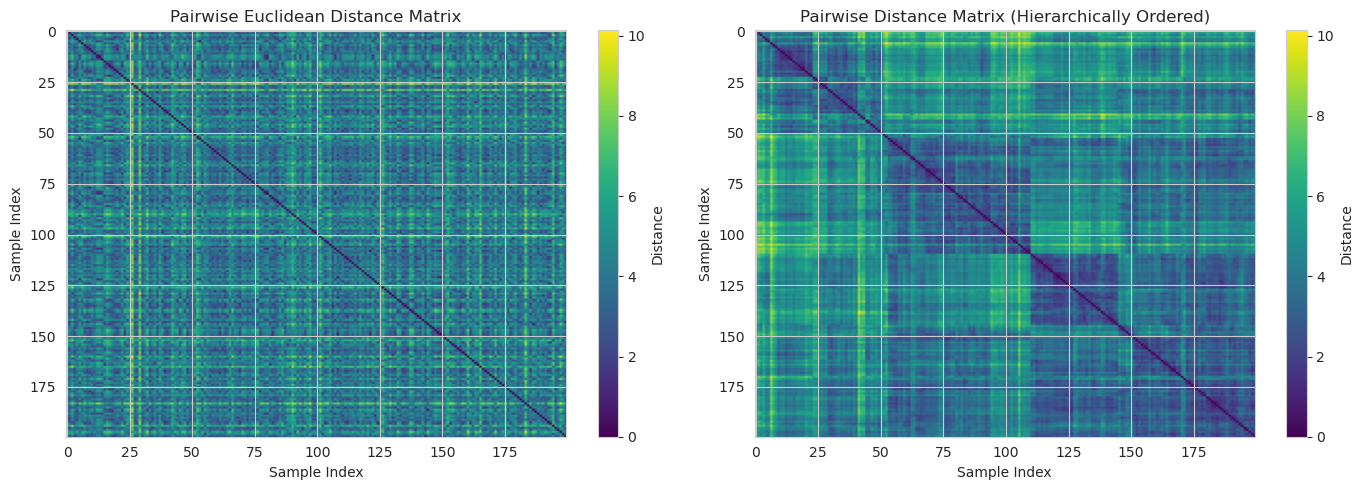

Average pairwise distance: 4.283
Min pairwise distance: 0.481
Max pairwise distance: 10.137


In [33]:
# Distance matrix on a sample
sample_size = 200
sample_idx = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[sample_idx]

# Compute pairwise distances
dist_matrix = squareform(pdist(X_sample, metric='euclidean'))

# Sort by hierarchical clustering
from scipy.cluster.hierarchy import dendrogram, linkage
linkage_matrix = linkage(X_sample, method='ward')
dendro = dendrogram(linkage_matrix, no_plot=True)
dendro_idx = dendro['leaves']

# Visualize distance matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distance matrix heatmap
im1 = axes[0].imshow(dist_matrix, cmap='viridis', aspect='auto')
axes[0].set_title('Pairwise Euclidean Distance Matrix')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Sample Index')
plt.colorbar(im1, ax=axes[0], label='Distance')

# Reordered distance matrix
dist_reordered = dist_matrix[dendro_idx][:, dendro_idx]
im2 = axes[1].imshow(dist_reordered, cmap='viridis', aspect='auto')
axes[1].set_title('Pairwise Distance Matrix (Hierarchically Ordered)')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Sample Index')
plt.colorbar(im2, ax=axes[1], label='Distance')

plt.tight_layout()
plt.show()

print(f"Average pairwise distance: {np.mean(dist_matrix):.3f}")
print(f"Min pairwise distance: {np.min(dist_matrix[dist_matrix > 0]):.3f}")
print(f"Max pairwise distance: {np.max(dist_matrix):.3f}")

## 6. KEY INSIGHTS: Multivariate vs. Pairwise Analysis

### What Pairwise Analysis Reveals:
1. **Individual correlations:** Direct relationships between pairs of variables
2. **Dependent trends:** How one variable responds to changes in another
3. **Outliers in 2D:** Unusual pairs of values
4. **Simple patterns:** Linear or obvious non-linear relationships

### What Pairwise Analysis Misses:
1. **Multivariate outliers:** Points unusual in multiple dimensions simultaneously
2. **Latent factors:** Underlying common causes affecting multiple variables
3. **Data dimensionality:** True effective number of dimensions needed
4. **Natural groupings:** Clusters that emerge from multivariate structure
5. **Global patterns:** Overall structure and relationships among quality levels

### What Multivariate Analysis Reveals:
1. **PCA shows** that wine data can be **effectively compressed** from 11 dimensions to ~3-4 dimensions while retaining 80-85% of variance
2. **Clustering reveals** that wines naturally form **distinct groups** based on physicochemical properties
3. **Quality distribution** differs across clusters, suggesting **quality depends on combinations** of properties, not individual metrics
4. **Wine type (Red vs White)** shows **clear separation** in multivariate space, indicating different physicochemical profiles
5. **Correlation structure** shows that variables form **coherent groups** (e.g., acidity-related, sulfur-related, density-related)

In [35]:
loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f'PC{i+1}' for i in range(len(pca_full.components_))],
    index=features
)

# Summary statistics
print("="*70)
print("MULTIVARIATE ANALYSIS SUMMARY")
print("="*70)

print("\n1. PCA FINDINGS:")
print(f"   - First 2 components explain {cumsum_var[1]:.1%} of variance")
print(f"   - First 3 components explain {cumsum_var[2]:.1%} of variance")
print(f"   - Effective dimensionality: ~4 dimensions (for 80% variance)")

print("\n2. CLUSTERING FINDINGS:")
print(f"   - Optimal number of clusters: {optimal_k}")
print(f"   - Silhouette score: {silhouette_scores[optimal_k-2]:.3f}")
print(f"   - Cluster sizes: {np.bincount(clusters)}")

print("\n3. QUALITY BY WINE TYPE:")
for wine_type in ['Red', 'White']:
    data = df[df['wine_type'] == wine_type]
    print(f"   {wine_type} wines: Mean quality = {data['quality'].mean():.2f} (σ={data['quality'].std():.2f})")

print("\n4. TOP CORRELATED FEATURES WITH QUALITY:")
for i, (feature, corr) in enumerate(corr_matrix['quality'].abs().sort_values(ascending=False)[1:6].items(), 1):
    actual_corr = corr_matrix.loc[feature, 'quality']
    print(f"   {i}. {feature:25s}: r = {actual_corr:7.3f}")

print("\n5. VARIABLE GROUPING (by PC loadings):")
print("   PC1 (contrast between acidity/density and alcohol/sulphates):")
pc1_contrib = loadings['PC1'].abs().sort_values(ascending=False)
for feature in pc1_contrib.head(5).index:
    print(f"      - {feature:25s}: {loadings.loc[feature, 'PC1']:7.3f}")

print("\n" + "="*70)

MULTIVARIATE ANALYSIS SUMMARY

1. PCA FINDINGS:
   - First 2 components explain 50.2% of variance
   - First 3 components explain 64.4% of variance
   - Effective dimensionality: ~4 dimensions (for 80% variance)

2. CLUSTERING FINDINGS:
   - Optimal number of clusters: 4
   - Silhouette score: 0.248
   - Cluster sizes: [1006 1873  687 2931]

3. QUALITY BY WINE TYPE:
   Red wines: Mean quality = 5.64 (σ=0.81)
   White wines: Mean quality = 5.88 (σ=0.89)

4. TOP CORRELATED FEATURES WITH QUALITY:
   1. alcohol                  : r =   0.444
   2. density                  : r =  -0.306
   3. volatile acidity         : r =  -0.266
   4. chlorides                : r =  -0.201
   5. citric acid              : r =   0.086

5. VARIABLE GROUPING (by PC loadings):
   PC1 (contrast between acidity/density and alcohol/sulphates):
      - total sulfur dioxide     :   0.487
      - free sulfur dioxide      :   0.431
      - volatile acidity         :  -0.381
      - residual sugar           :   0.346

## 7. Conclusions

**1. Data Dimensionality**
- The Wine Quality dataset contains 11 physicochemical variables, but the effective dimensionality is much lower (~3-4 dimensions)
- This suggests underlying latent structures or common factors influencing wine properties

**2. Natural Groupings**
- Wines naturally cluster into distinct groups based on their physicochemical profiles
- These clusters show different average quality scores, suggesting quality emerges from combinations of properties

**3. Variable Relationships**
- Variables are not independent; they form coherent groups:
  - **Acidity group:** Fixed acidity, citric acid, pH
  - **Sulfur group:** Free and total sulfur dioxide
  - **Density/Composition:** Alcohol, density, residual sugar
  - **Chlorides:** Often stands alone

**4. Wine Type Differences**
- Red and white wines occupy distinct regions in multivariate space
- They have different physicochemical profiles despite sharing the same 11 variables

**5. Quality Prediction**
- While individual correlations with quality exist (alcohol, sulphates), the best models likely combine multiple variables
- Multivariate patterns matter more than individual feature values

### Why Multivariate Analysis Matters

Pairwise analysis can answer "Do X and Y go together?" but multivariate analysis answers:
- "What is the overall structure of the data?"
- "How many underlying factors drive this system?"
- "What are natural groupings in this data?"
- "Which combinations of features characterize different outcomes?"

For the Wine Quality dataset, multivariate techniques reveal that **wine quality is a property of the entire physicochemical profile, not of any single or pair of characteristics.**